In [1]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [6]:
# ==========================================
# 3. LOAD DATASET
# ==========================================
df = pd.read_csv(r"C:\Users\pravi\PycharmProjects\JupyterProject\Employee Attrition Prediction\employee_attrition_hr_2026.csv")

print("=" * 70)
print("EMPLOYEE ATTRITION HR ANALYSIS")
print("=" * 70)

print("\nDataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

EMPLOYEE ATTRITION HR ANALYSIS

Dataset shape: (5000, 29)

First 5 rows:
   employee_id  age  gender marital_status education_level   department  \
0         1001   37    Male       Divorced         Masters  Engineering   
1         1002   24  Female        Married       Bachelors      Finance   
2         1003   24  Female         Single       Bachelors    Marketing   
3         1004   44    Male         Single       Bachelors        Sales   
4         1005   37  Female       Divorced       Bachelors        Sales   

                job_role  job_level  monthly_income  stock_option_level  ...  \
0    Engineering Manager          3            7365                   0  ...   
1        Finance Manager          2            4746                   2  ...   
2   Marketing Specialist          1            2740                   2  ...   
3          Sales Manager          4            7334                   1  ...   
4  Sales Development Rep          3            9096                   0  ...

In [7]:
# ==========================================
# 4. BASIC DATA UNDERSTANDING
# ==========================================
print("\n" + "=" * 70)
print("DATA TYPES")
print("=" * 70)
print(df.dtypes)

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

print("\n" + "=" * 70)
print("DUPLICATE ROWS")
print("=" * 70)
print("Duplicate rows:", df.duplicated().sum())

print("\n" + "=" * 70)
print("TARGET DISTRIBUTION")
print("=" * 70)
print(df["attrition"].value_counts())
print("\nTarget percentage:")
print((df["attrition"].value_counts(normalize=True) * 100).round(2))


DATA TYPES
employee_id                        int64
age                                int64
gender                            object
marital_status                    object
education_level                   object
department                        object
job_role                          object
job_level                          int64
monthly_income                     int64
stock_option_level                 int64
salary_hike_pct                  float64
years_at_company                 float64
total_working_years              float64
years_since_promotion            float64
num_prior_companies                int64
work_mode                         object
commute_minutes                    int64
overtime_hours_per_week          float64
business_travel_days_per_year      int64
training_hours                     int64
manager_support_score            float64
burnout_score                    float64
engagement_score                 float64
work_life_balance_score          float64
perf

In [8]:
# ==========================================
# 5. DATA CLEANING
# ==========================================
# Remove exact duplicate rows if present.
df = df.drop_duplicates().copy()

# Employee ID identifies an employee but should not be used as a
# predictive feature because it has no meaningful business signal.
id_column = "employee_id"

# Create binary target:
# Yes = 1 -> employee left
# No  = 0 -> employee stayed
df["attrition_flag"] = df["attrition"].map({"No": 0, "Yes": 1})

if df["attrition_flag"].isnull().any():
    raise ValueError("Unexpected values found in attrition column.")

In [9]:
# ==========================================
# 6. DESCRIPTIVE ANALYSIS
# ==========================================
print("\n" + "=" * 70)
print("DESCRIPTIVE ANALYSIS")
print("=" * 70)

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
numeric_columns = [
    c for c in numeric_columns
    if c not in [id_column, "attrition_flag"]
]

print("\nNumerical summary:")
print(df[numeric_columns].describe().round(2).T)

categorical_columns = df.select_dtypes(include=["object", "bool"]).columns.tolist()
categorical_columns = [
    c for c in categorical_columns
    if c != "attrition"
]

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(15))


DESCRIPTIVE ANALYSIS

Numerical summary:
                                count     mean      std     min      25%  \
age                            5000.0    37.12     8.23    21.0    31.00   
job_level                      5000.0     2.93     1.20     1.0     2.00   
monthly_income                 5000.0  6990.72  2701.90  1500.0  4971.00   
stock_option_level             5000.0     1.09     0.94     0.0     0.00   
salary_hike_pct                5000.0    11.52     3.41     0.0     9.30   
years_at_company               5000.0     6.72     3.50     0.0     4.28   
total_working_years            5000.0    11.70     5.00     0.0     8.30   
years_since_promotion          5000.0     1.97     1.63     0.0     0.80   
num_prior_companies            5000.0     1.81     1.35     0.0     1.00   
commute_minutes                5000.0    31.16    19.44     0.0    14.00   
overtime_hours_per_week        5000.0     6.83     4.47     0.0     3.60   
business_travel_days_per_year  5000.0    10.82

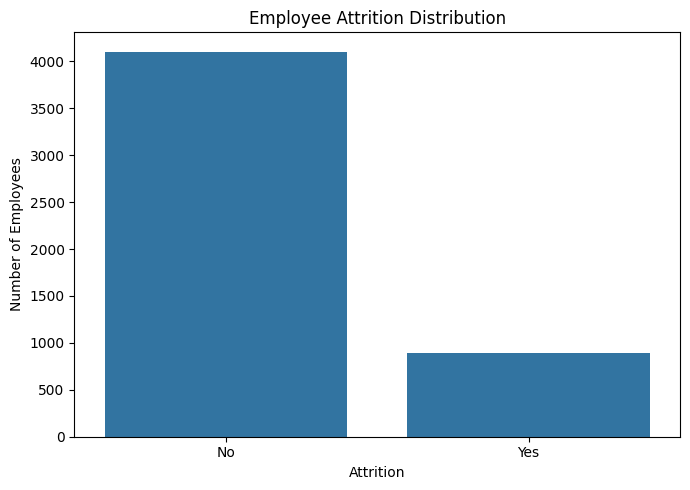

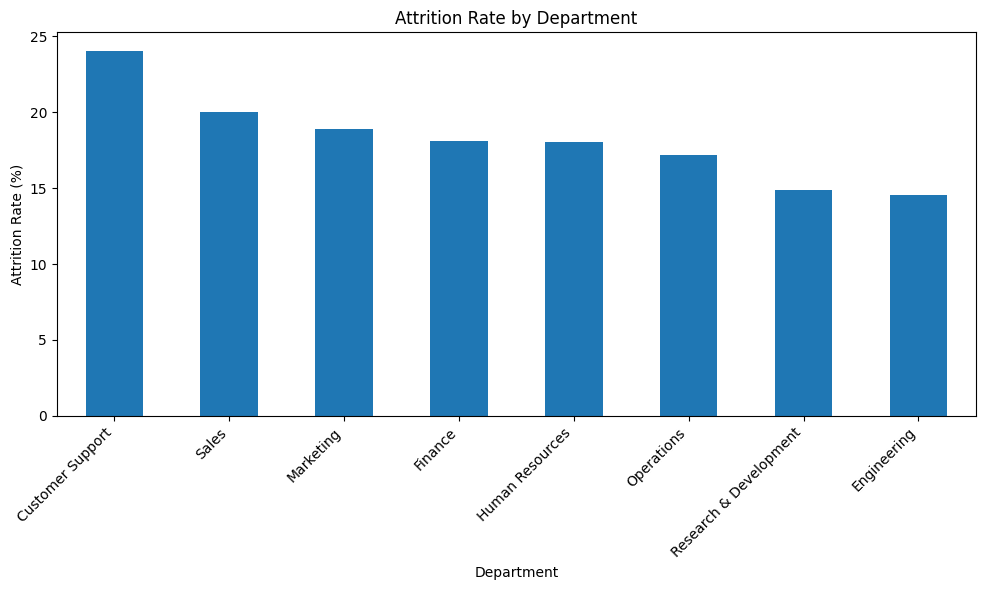

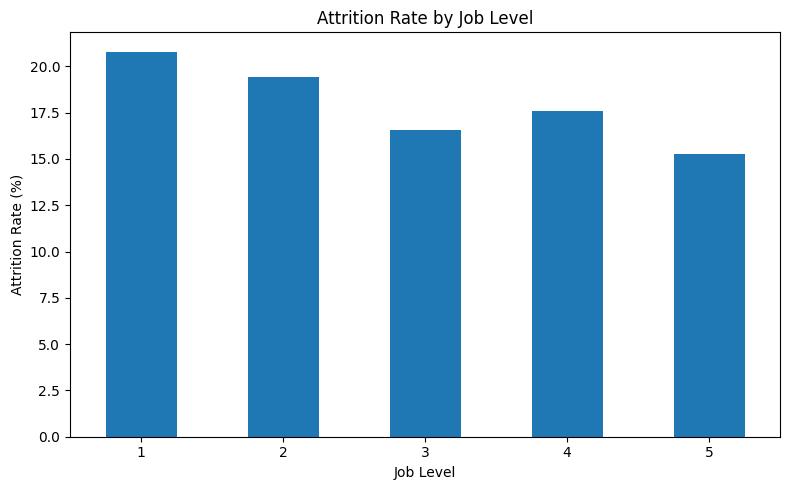

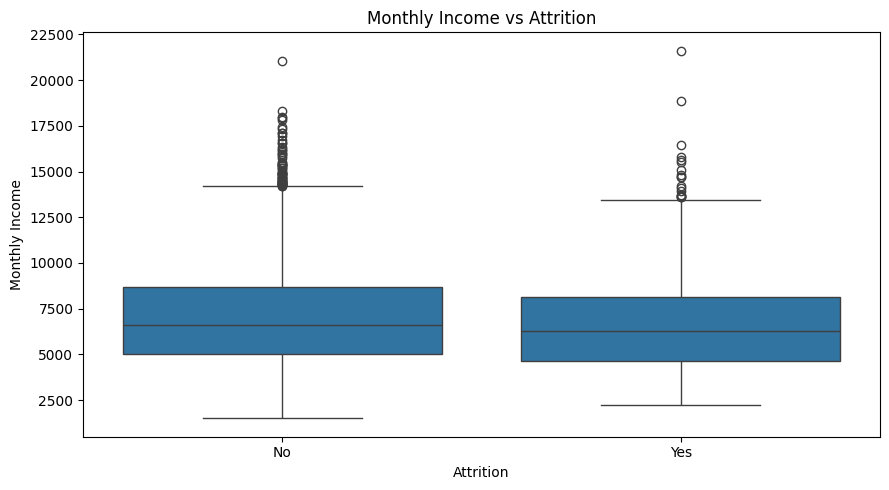

In [10]:
# ==========================================
# 7. DESCRIPTIVE VISUALIZATIONS
# ==========================================

# 7.1 Overall attrition distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="attrition")
plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.tight_layout()
plt.show()

# 7.2 Attrition by department
dept_attrition = pd.crosstab(
    df["department"],
    df["attrition"],
    normalize="index"
) * 100

plt.figure(figsize=(10, 6))
dept_attrition["Yes"].sort_values(ascending=False).plot(kind="bar")
plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 7.3 Attrition by job level
joblevel_attrition = pd.crosstab(
    df["job_level"],
    df["attrition"],
    normalize="index"
) * 100

plt.figure(figsize=(8, 5))
joblevel_attrition["Yes"].plot(kind="bar")
plt.title("Attrition Rate by Job Level")
plt.xlabel("Job Level")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 7.4 Salary distribution by attrition
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="attrition", y="monthly_income")
plt.title("Monthly Income vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.tight_layout()
plt.show()


DIAGNOSTIC ANALYSIS

Attrition by department:
                        count  attrition_count  attrition_rate
department                                                    
Customer Support          636              153           24.06
Sales                     835              167           20.00
Marketing                 440               83           18.86
Finance                   436               79           18.12
Human Resources           244               44           18.03
Operations                663              114           17.19
Research & Development    410               61           14.88
Engineering              1336              194           14.52

Attrition by job role:
                          count  attrition_count  attrition_rate
job_role                                                        
Support Team Lead           204               53           25.98
Support Specialist          218               55           25.23
Content Strategist          138        

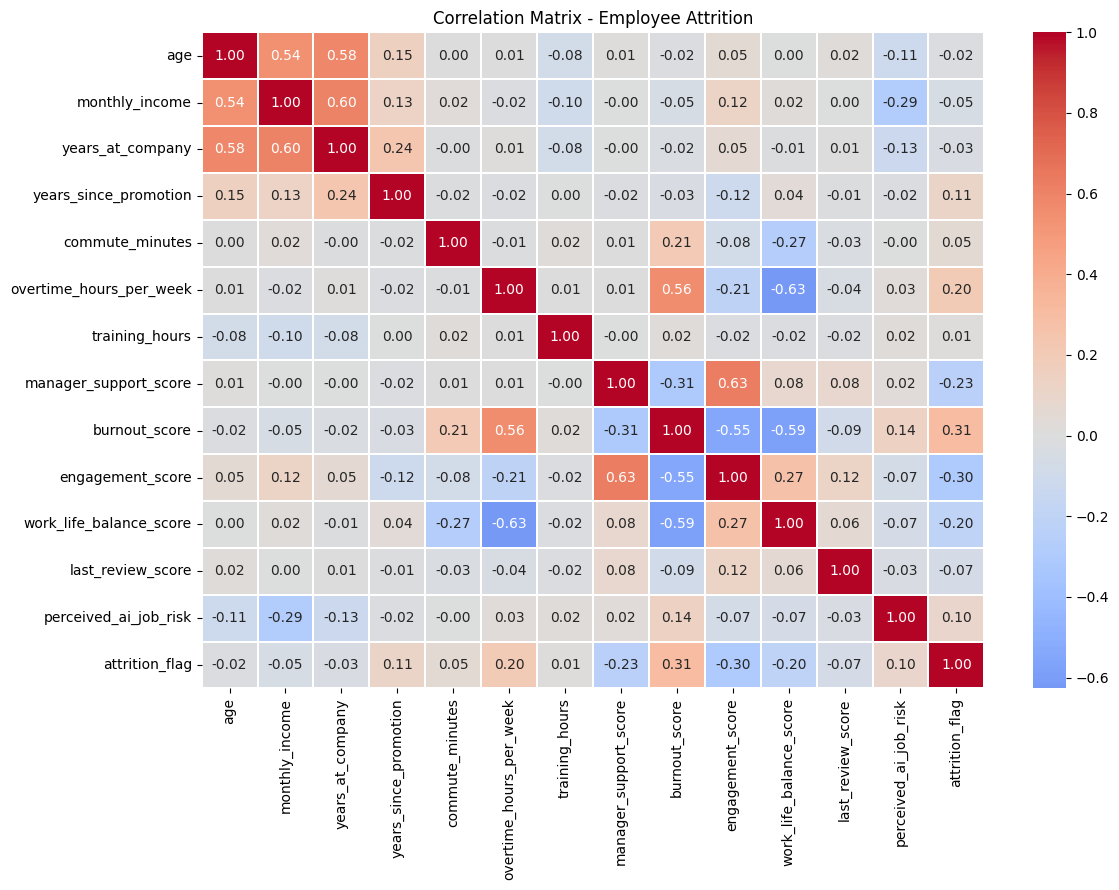

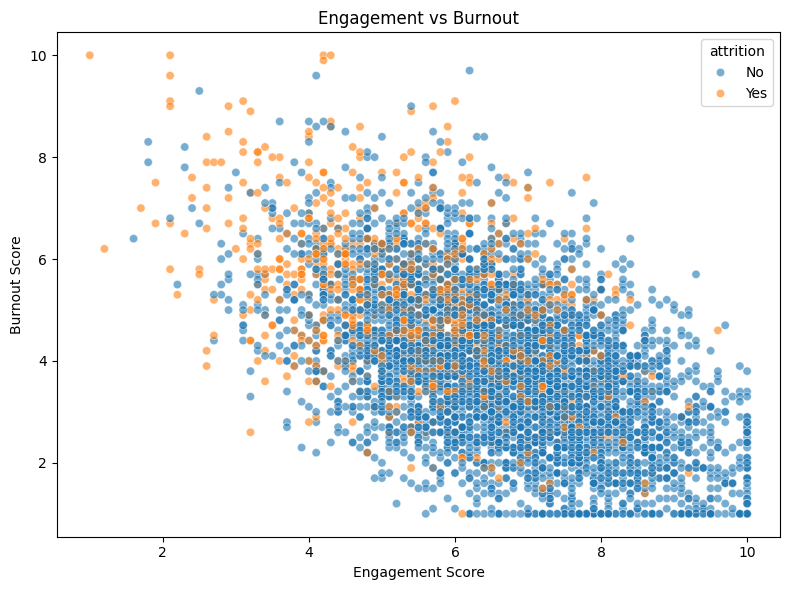

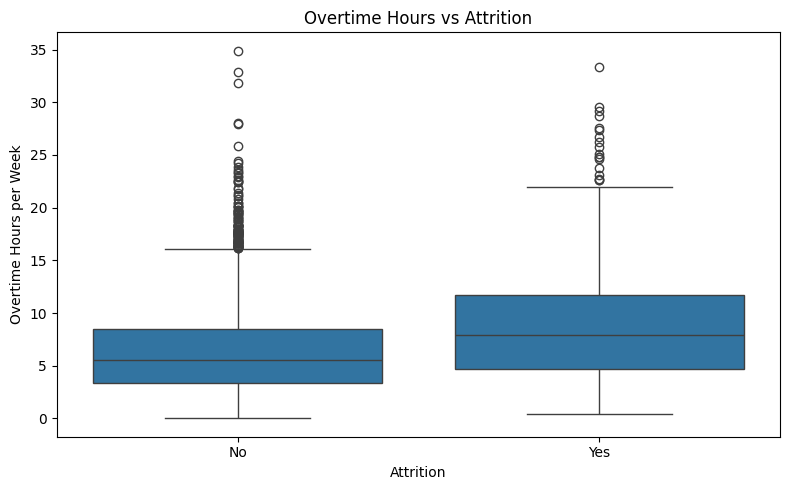

<Figure size 900x600 with 0 Axes>

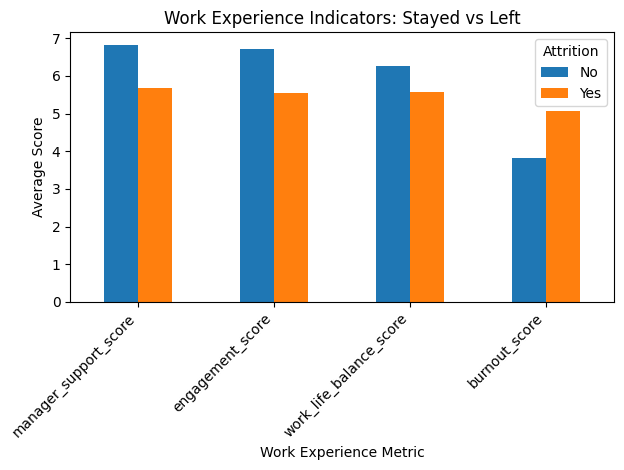

In [11]:
# ==========================================
# 8. DIAGNOSTIC ANALYSIS
# ==========================================
print("\n" + "=" * 70)
print("DIAGNOSTIC ANALYSIS")
print("=" * 70)

# Helper function for attrition rate
def attrition_rate_by(column):
    result = (
        df.groupby(column)["attrition_flag"]
        .agg(["count", "sum", "mean"])
        .rename(columns={"sum": "attrition_count", "mean": "attrition_rate"})
    )
    result["attrition_rate"] = result["attrition_rate"] * 100
    return result.sort_values("attrition_rate", ascending=False)

print("\nAttrition by department:")
print(attrition_rate_by("department").round(2))

print("\nAttrition by job role:")
print(attrition_rate_by("job_role").round(2))

print("\nAttrition by work mode:")
print(attrition_rate_by("work_mode").round(2))

# Compare important numerical variables for employees who stayed vs left.
diagnostic_variables = [
    "age",
    "monthly_income",
    "years_at_company",
    "years_since_promotion",
    "commute_minutes",
    "overtime_hours_per_week",
    "training_hours",
    "manager_support_score",
    "burnout_score",
    "engagement_score",
    "work_life_balance_score",
    "last_review_score",
    "perceived_ai_job_risk"
]

available_diagnostic_variables = [
    c for c in diagnostic_variables if c in df.columns
]

diagnostic_summary = (
    df.groupby("attrition")[available_diagnostic_variables]
    .mean()
    .T
)

print("\nMean comparison: Stayed vs Left")
print(diagnostic_summary.round(2))

# 8.1 Correlation heatmap for numeric variables
corr_columns = available_diagnostic_variables + ["attrition_flag"]
corr_matrix = df[corr_columns].corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)
plt.title("Correlation Matrix - Employee Attrition")
plt.tight_layout()
plt.show()

# 8.2 Burnout vs engagement
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="engagement_score",
    y="burnout_score",
    hue="attrition",
    alpha=0.6
)
plt.title("Engagement vs Burnout")
plt.xlabel("Engagement Score")
plt.ylabel("Burnout Score")
plt.tight_layout()
plt.show()

# 8.3 Overtime by attrition
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="attrition",
    y="overtime_hours_per_week"
)
plt.title("Overtime Hours vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Overtime Hours per Week")
plt.tight_layout()
plt.show()

# 8.4 Satisfaction-related factors
satisfaction_variables = [
    "manager_support_score",
    "engagement_score",
    "work_life_balance_score",
    "burnout_score"
]

satisfaction_means = df.groupby("attrition")[satisfaction_variables].mean().T

plt.figure(figsize=(9, 6))
satisfaction_means.plot(kind="bar")
plt.title("Work Experience Indicators: Stayed vs Left")
plt.xlabel("Work Experience Metric")
plt.ylabel("Average Score")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Attrition")
plt.tight_layout()
plt.show()

In [12]:
# ==========================================
# 9. PREDICTIVE ANALYSIS
# ==========================================
print("\n" + "=" * 70)
print("PREDICTIVE ANALYSIS")
print("=" * 70)

# Do not use employee ID or the original target text as predictors.
feature_columns = [
    c for c in df.columns
    if c not in [id_column, "attrition", "attrition_flag"]
]

X = df[feature_columns]
y = df["attrition_flag"]

categorical_features = X.select_dtypes(
    include=["object", "bool"]
).columns.tolist()

numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

# Numeric preprocessing:
# - Fill missing numeric values with median
# - Standardize values
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing:
# - Fill missing values with most frequent category
# - Convert categories into dummy variables
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Logistic Regression is used because:
# 1. This is a binary classification problem.
# 2. It produces interpretable probabilities.
# 3. HR teams can use risk probability for retention prioritization.
model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

# Stratification preserves the Yes/No attrition ratio.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining rows:", len(X_train))
print("Testing rows:", len(X_test))

# Train model
model_pipeline.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline.predict(X_test)
y_prob = model_pipeline.predict_proba(X_test)[:, 1]


PREDICTIVE ANALYSIS

Training rows: 4000
Testing rows: 1000


In [ ]:
# ==========================================
# 10. MODEL EVALUATION
# ==========================================
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)

print("\n" + "=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")
print(f"ROC-AUC  : {roc_auc:.3f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Stayed", "Left"],
        zero_division=0
    )
)



In [ ]:
# ==========================================
# 11. CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Stayed", "Predicted Left"],
    yticklabels=["Actual Stayed", "Actual Left"]
)
plt.title("Confusion Matrix - Employee Attrition")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 12. ROC CURVE
# ==========================================
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve - Employee Attrition Prediction")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 13. MODEL FEATURE IMPORTANCE
# ==========================================
# For logistic regression, coefficient magnitude shows the strength
# of a feature after preprocessing.
feature_names = model_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = model_pipeline.named_steps[
    "model"
].coef_[0]

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "absolute_coefficient": np.abs(coefficients)
})

feature_importance = feature_importance.sort_values(
    "absolute_coefficient",
    ascending=False
)

print("\nTop 20 model signals:")
print(
    feature_importance[
        ["feature", "coefficient"]
    ].head(20).to_string(index=False)
)

top_features = feature_importance.head(15).sort_values(
    "coefficient"
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_features["feature"],
    top_features["coefficient"]
)
plt.axvline(0, linestyle="--")
plt.title("Top Predictive Factors - Logistic Regression")
plt.xlabel("Model Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 14. EMPLOYEE ATTRITION RISK SCORING
# ==========================================
# Create risk scores for all employees.
all_probabilities = model_pipeline.predict_proba(X)[:, 1]

risk_df = df[
    [id_column, "department", "job_role", "job_level",
     "years_at_company", "monthly_income",
     "engagement_score", "burnout_score", "manager_support_score"]
].copy()

risk_df["attrition_probability"] = all_probabilities

# Business-friendly risk bands.
risk_df["risk_band"] = pd.cut(
    risk_df["attrition_probability"],
    bins=[-0.01, 0.30, 0.60, 1.00],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

risk_df = risk_df.sort_values(
    "attrition_probability",
    ascending=False
)

print("\n" + "=" * 70)
print("TOP EMPLOYEES BY PREDICTED ATTRITION RISK")
print("=" * 70)

print(
    risk_df.head(20).to_string(index=False)
)

print("\nRisk band distribution:")
print(risk_df["risk_band"].value_counts().sort_index())

In [ ]:
# ==========================================
# 15. RISK BAND VISUALIZATION
# ==========================================
risk_counts = risk_df["risk_band"].value_counts().reindex(
    ["Low Risk", "Medium Risk", "High Risk"]
)

plt.figure(figsize=(8, 5))
risk_counts.plot(kind="bar")
plt.title("Employees by Predicted Attrition Risk Band")
plt.xlabel("Risk Band")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 16. SAVE RISK RESULTS
# ==========================================
risk_output_path = os.path.join(
    PROJECT_FOLDER,
    "employee_attrition_risk_predictions.csv"
)

risk_df.to_csv(risk_output_path, index=False)

print("\nRisk prediction file saved to:")
print(risk_output_path)

In [13]:
# ==========================================
# 17. BUSINESS CONCLUSION
# ==========================================
print("\n" + "=" * 70)
print("BUSINESS INTERPRETATION")
print("=" * 70)

print("""
The model estimates which employees have a higher probability of attrition.

HR can use the risk score as an EARLY-WARNING signal, not as an automatic
decision to terminate, promote, or penalize an employee.

Recommended retention workflow:
1. Identify High Risk employees.
2. Review the model's major contributing factors.
3. Conduct a fair retention conversation.
4. Investigate workload, burnout, engagement, manager support,
   compensation, career growth, and work-life balance.
5. Offer appropriate interventions where justified.
6. Re-score employees periodically.

Important:
A machine-learning prediction is a risk signal, not proof that an employee
will leave. Human review and fairness checks are required before HR action.
""")

print("\nAnalysis completed successfully.")



BUSINESS INTERPRETATION

The model estimates which employees have a higher probability of attrition.

HR can use the risk score as an EARLY-WARNING signal, not as an automatic
decision to terminate, promote, or penalize an employee.

Recommended retention workflow:
1. Identify High Risk employees.
2. Review the model's major contributing factors.
3. Conduct a fair retention conversation.
4. Investigate workload, burnout, engagement, manager support,
   compensation, career growth, and work-life balance.
5. Offer appropriate interventions where justified.
6. Re-score employees periodically.

Important:
A machine-learning prediction is a risk signal, not proof that an employee
will leave. Human review and fairness checks are required before HR action.


Analysis completed successfully.
